# Jenkins?
Jenkins is an open‑source CI/CD tool. It helps automate:

Build Test Deployment

Jenkins runs jobs when:

Code is pushed to GitHub A schedule is triggered A manual run is started

✅ Jenkins acts as the automation engine for CI/CD.

🔹 How Jenkins Works (Simple Flow)

Developer pushes code to GitHub GitHub triggers Jenkins Jenkins:

Pulls code Runs shell scripts Builds application Deploys to server

✅ Everything happens automatically.

# CI/CD?
CI/CD stands for:

CI – Continuous Integration CD – Continuous Delivery / Continuous Deployment

It is a process that helps developers and DevOps teams automate code build, test, and deployment.

Continuous Integration (CI) means:
Developers frequently push code to a shared repository (like GitHub), and the system automatically builds and tests the code.

Continuous Delivery (CD):
Code is automatically built and tested Deployment is ready, but may need manual approval

Continuous Deployment:

Code is automatically built, tested, and deployed to production

✅ CD ensures code reaches servers quickly and consistently.

Note for my undersatnding : Continuous delivery means clicking button on app to get the app updated. and continuous deployment means apps getting updated automatically.

# Installation of jenkins : Jenkins is GUI made on Java
before jenkin install java on EC2 server.(get command from google)
then install jenkins on EC2 server. (start jenkins : sudo systemctl start jenkins)
then check jenkins is running or not (systemctl status jenkins)
command: sudo sytemctl enable jenkins (when system start that time jenkins will also start)
go to EC2 server and copy the ip address and edit the inbound rule to add the 8080 to make the jenkins run over port 8080.
open http://15.135.216.163:8080/ jenkins open
command : curl ifconfig.me (run this to get the actual public IP) if instance restarted then ip will get change for instance and jenkins
Jenkins UI/dashboard/Jobs
Jenkins Dashboard is the main interface used to monitor and manage jobs, builds, and pipelines.

When you open Jenkins, you get:

List of jobs Build status (✅ success / ❌ failed) Build history Menu options (New Item, Manage Jenkins)

# Jenkins freestyle project
A Freestyle project is a basic Jenkins job used to execute build steps like shell commands or scripts.

# Declarative pipelines
A Declarative Pipeline is a modern Jenkins pipeline written as code using Groovy syntax. Whatever we writing in pipeline definition is called a groovy script.

✅ Key Points

Defined using Jenkinsfile Written in Groovy-based syntax Used in real DevOps projects ✅ Structured into stages like: Build Test Deploy

Jenkin Controller/Agents
Jenkins Agents are worker machines that execute jobs assigned by Jenkins controller.

Jenkins controller gives work to agent so that in agent memorary issue should not come and it will be safe

✅ Why Agents are needed

Reduce load on Jenkins master/controller Avoid memory issues Enable parallel jobs Run jobs on different systems (Linux, Windows, Docker)

“I installed Jenkins on EC2, configured security groups, resolved network access issues, and created CI/CD jobs and pipelines.”

✅ Steps to Connect Jenkins Master with Agent (Corrected)

🔹 Step 1: Generate SSH keys (On Master)

cd ~/.ssh ls ssh-keygen

👉 This creates:

Private Key → id_rsa Public Key → id_rsa.pub

🔹 Step 2: Copy Public Key cat id_rsa.pub

🔹 Step 3: Add key in Agent machine

cd ~/.ssh nano authorized_keys

🔹 Step 4: Save and exit Now: ✅ Master can SSH into Agent ✅ Jenkins can connect to agent

# Pipeline creation (DjangoCICD)
created pipeline with simple groovy script.save it->build now.
modifield pipeline and clone the github code into agent Liha.
next build it for this we need docker so install docker with command (sudo apt-get install docker.io) and do docker ps to see running or not if permission is denied then type command (sudo usermod -aG docker $USER && newgrp docker) to get the access.
Note : whenever we install any plugins in jenkins it restart.
next deploy the code using docker run it deployed the code.

#  CI/CD Pipeline?
🔷 1. CI/CD pipeline is an automated process to build, test and deploy application code.

Flow:
Developer → GitHub → Jenkins → Build → Test → Docker → Deploy

🔷 2. Prerequisites (VERY IMPORTANT)
Before creating pipeline, you must have:
✅ 1. EC2 Instance

Jenkins installed
Public IP + security group configured

✅ 2. Jenkins installed
sudo apt update
sudo apt install openjdk-21-jdk -y
sudo apt install jenkins -y
sudo systemctl start jenkins

✅ 3. Docker installed
sudo apt-get install docker.io -y

🔷 3. Jenkins Basic Concepts
✅ Jenkins Components

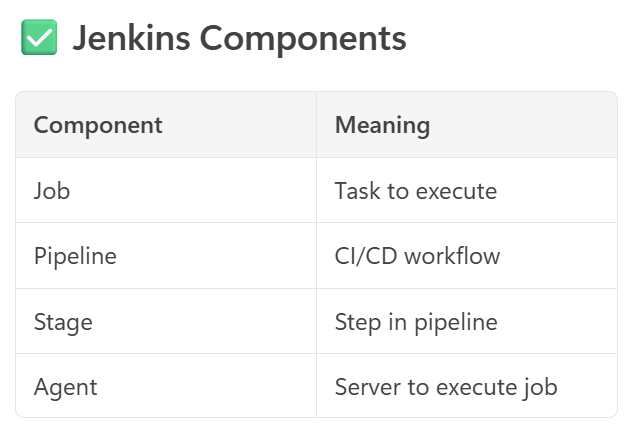

✅ Jenkins Architecture
Master → Controls pipeline
Agent → Executes tasks

🔷 4. Creating Pipeline Job

✅ Step 1: Create Job

Go to Jenkins UI
Click → New Item
Choose → Pipeline
Name: DjangoCICD

✅ Step 2: Configure Pipeline
🔹 General Section
Description: Django CI/CD Pipeline

🔹 GitHub Project
Add:
Repo URL

🔹 Build Trigger
GitHub hook ✅

👉 Pipeline runs automatically on push

🔷 5. Declarative Pipeline (Core Part ✅)

✅ Pipeline Structure

pipeline {
    agent { label 'liha' }

    stages {

        stage('Code') {
            steps {
                git url: 'https://github.com/...', branch: 'main'
            }
        }

        stage('Build') {
            steps {
                sh 'docker build -t notes-app:latest .'
            }
        }

        stage('Test') {
            steps {
                echo 'Testing phase'
            }
        }

        stage('Deploy') {
            steps {
                sh '''
                docker stop notes-container || true
                docker rm notes-container || true
                docker run -d -p 8000:8000 --name notes-container notes-app:latest
                '''
            }
        }

    }
}

🔷 6. Pipeline Stages Explanation
✅ 1. Code Stage
git url: "repo"
👉 Clones project from GitHub
👉 Always runs first

✅ 2. Build Stage
docker build -t notes-app .
👉 Creates Docker image

✅ 3. Test Stage
echo "Testing"
👉 Placeholder for:

Unit testing
Automation testing

✅ 4. Deploy Stage
docker run -p 8000:8000
👉 Runs container
👉 Deploys application

🔷 7. Important Docker Commands (VERY IMPORTANT)
✅ Build Image: docker build -t notes-app
✅ Run Container: docker run -d -p 8000:8000 notes-app
✅ Stop Container:docker stop <id>
✅ Remove Container: docker rm <id>
✅ Check Running Containers: docker ps
✅ View Logs:docker logs <id>


🔷 8. Common Errors & Fixes ⭐
✅ 1. Jenkins restarts after plugin install
👉 NORMAL ✅

✅ 2. Permission denied (Docker)
✅ Fix: sudo usermod -aG docker $USER

✅ 3. Port already allocated
✅ Fix: docker stop container, docker rm container

✅ 4. App not opening
Check:

docker ps
docker logs
Security group (port 8000)

✅ 5. Django DB Error
Host None error

✅ Fix: Use SQLite or configure DB


# Docker Hub

🔷 1. What is DockerHub?
DockerHub is a cloud platform used to store and share Docker images.

✅ Why we use DockerHub?
Store images ✅
Share images ✅
Deploy anywhere ✅

🔷 2. Step 1: Create DockerHub Account
https://hub.docker.com

✅ Create account
✅ Login


🔷 3. Push Image to DockerHub (Concept)
Local Docker Image → Tag → Push → DockerHub ✅

🔷 4. DockerHub Authentication in Jenkins
✅ Solution: Credential Binding
👉 Jenkins provides secure credential storage

✅ Steps to Add Credentials

🔹 Step 1:
Go to:
Manage Jenkins → Credentials → Global


🔹 Step 2:
Click:Add Credentials


🔹 Step 3:
Choose: Username with password ✅


🔹 Step 4:
Enter:
Username → DockerHub username  
Password → DockerHub token ✅  
ID → dockerHubCred ✅

 ✅ How to generate DockerHub token
Go to DockerHub:
Account Settings → Security → Access Tokens

✅ Generate token
✅ Use instead of password ✅

🔷 5. Jenkins Pipeline – Push to DockerHub

stage("Push to DockerHub") {
    steps {
        echo "this is pushing image to docker hub"

        withCredentials([usernamePassword(
            credentialsId: "dockerHubCred",
            usernameVariable: "dockerHubUser",
            passwordVariable: "dockerHubPass"
        )]) {

            sh "docker login -u ${dockerHubUser} -p ${dockerHubPass}"

            sh "docker tag notes-app:latest ${dockerHubUser}/notes-app:latest"

            sh "docker push ${dockerHubUser}/notes-app:latest"
        }
    }
}

✅ Explanation

✅ withCredentials()
👉 Injects hidden credentials securely ✅

✅ docker login
👉 Logs into DockerHub

✅ docker tag
👉 Tags image:
local → remote format ✅

✅ docker push
👉 Uploads image to DockerHub

🔷 6. Automate Pipeline using GitHub Webhook ⭐

✅ Goal
👉 Run pipeline automatically when code is pushed

✅ Step‑by‑Step

🔹 Step 1: Go to GitHub
Repository → Settings → Webhooks

🔹 Step 2: Click:
Add Webhook

🔹 Step 3: Add Payload URL
http://<jenkins-ip>:8080/github-webhook/

🔹 Step 4:
Set:
Content type → application/json ✅

🔹 Step 5:
Disable SSL verification (for testing):
Disable ✅

🔹 Step 6:
Choose:
Send me everything ✅

🔹 Step 7:
Click:
Add webhook ✅

🔷 7. Enable Jenkins Trigger

👉 Go to your Job:
Configure → Build Triggers


✅ Enable:
GitHub hook trigger for GITScm polling ✅

FULL PIPELINE FLOW
1. Code → GitHub ✅
2. Jenkins → Clone code ✅
3. Build → Docker build ✅
4. Test ✅
5. Push → DockerHub ✅
6. Deploy ✅


FULL FINAL PIPELINE (COMPLETE)
pipeline {
    agent any

    stages {

        stage("Code") {
            steps {
                git url: 'https://github.com/your-repo.git', branch: 'main'
            }
        }

        stage("Build") {
            steps {
                sh "docker build -t notes-app:latest ."
            }
        }

        stage("Push to DockerHub") {
            steps {
                withCredentials([usernamePassword(
                    credentialsId: "dockerHubCred",
                    usernameVariable: "dockerHubUser",
                    passwordVariable: "dockerHubPass"
                )]) {

                    sh "docker login -u ${dockerHubUser} -p ${dockerHubPass}"
                    sh "docker tag notes-app:latest ${dockerHubUser}/notes-app:latest"
                    sh "docker push ${dockerHubUser}/notes-app:latest"
                }
            }
        }

        stage("Deploy") {
            steps {
                sh """
                docker stop notes-container || true
                docker rm notes-container || true
                docker run -d -p 8000:8000 --name notes-container ${dockerHubUser}/notes-app:latest
                """
            }
        }

    }
}


# Shared Libraries

A Shared Library in Jenkins is a way to reuse common pipeline code across multiple Jenkins jobs.

Shared library in Jenkins allows us to reuse common pipeline code across multiple projects. We store reusable functions in a Git repository under the vars directory, configure it in Jenkins as a global library, and then call those functions in pipeline using the @Library annotation.

Shared Library = reusable functions stored in GitHub 

In your GitHub repo:
(shared-lib-repo)
│
├── vars/
│     └── hello.groovy ✅

vars Folder (MAIN CONCEPT)
👉 vars/ contains global functions

-> Configure in Jenkins :

🔹 Step 1:
Go to:
Manage Jenkins → System


🔹 Step 2:
Find:
Global Pipeline Libraries ✅

🔹 Step 3: Fill details
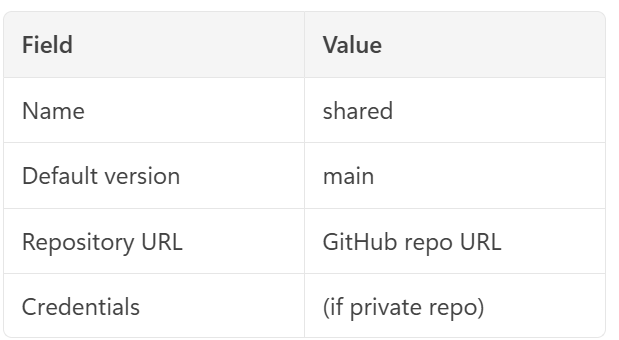

-> Use Shared Library in Pipeline :

@Library('shared') _

pipeline {
    agent any

    stages {
        stage('Hello') {
            steps {
                script {
                    hello()
                }
            }
        }
    }
}

✅ What happens here?
👉 Jenkins will:
1. Load library from GitHub ✅
2. Find hello.groovy ✅
3. Call hello() ✅


 Important Rule ⭐
👉 File must contain:
def call() {
    // code
}

Full Flow (IMPORTANT)
1. Create GitHub repo ✅
2. Add vars/hello.groovy ✅
3. Configure in Jenkins ✅
4. Use @Library ✅
5. Call function ✅

# User Management in Jenkins (Role Based) 

User management in Jenkins is used to create users and control what actions they can perform in Jenkins.

✅ Why we use it?
👉 To:
Restrict access ✅
Improve security ✅
Assign roles (Admin / Developer / Viewer) ✅

Types of Users
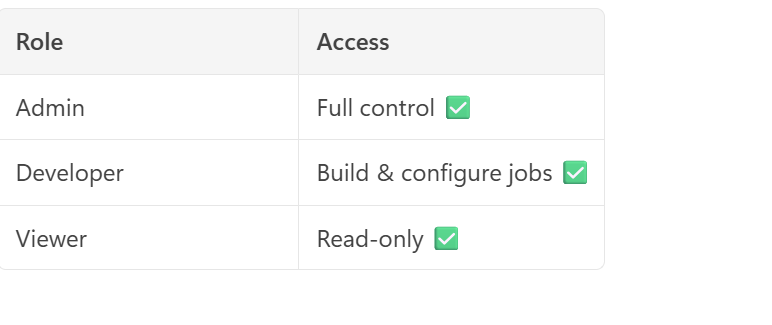

 Step 1: Create User in Jenkins

✅ Steps:

Go to: Jenkins Dashboard

Click:Manage Jenkins

Click:Users / Manage Users

Click:Create User


Enter:
Username  
Password  
Full Name  
Email

✅ Click → Create ✅

 Step 2: Install Role-Based Plugin

✅ Plugin Name:
Role-based Authorization Strategy ✅

✅ Steps:
Go to:
Manage Jenkins → Plugins
Search:Role-based Authorization Strategy
Click:Install ✅

✅ After install:
Jenkins will restart ✅

Step 3: Enable Role-Based Authorization

Go to:Manage Jenkins → Security

Find:Authorization

Select:Role-Based Strategy ✅

Save ✅

Step 4: Manage Roles
Go to: Manage Jenkins → Manage and Assign Roles ✅

Step 5: Create Roles

Go to:Manage Roles

Add Role: Example:
viewer
developer
admin

✅ Select permissions:
Example:
✅ Viewer:
✔ Overall Read
✔ Job Read


✅ Developer:
✔ Job Build
✔ Job Read
✔ Job Configure


✅ Admin:
✔ All permissions 

Step 6: Assign Roles to Users

✅ Go to: Assign Roles

✅ Under "Global roles":

Add user: username → gunjan


Assign role: ✔ viewer ✅

✅ Save ✅
